# AMEX Default Prediction

Interview-ready client behavior modeling project for predicting default risk on the American Express Kaggle dataset.

## Workflow
1. Data loading
2. EDA
3. Preprocessing and feature engineering
4. Baseline modeling (Logistic Regression + Gradient Boosting)
5. Evaluation (AUC, PR-AUC, decile lift)
6. Explainability and segment insights

## 1. Setup
- Primary data source: Google Drive folder `'/content/drive/MyDrive/amex_data_parquet'`.
- Required files:
  - `train_data.parquet`
  - `train_labels.csv`
- Optional one-time helper block in the next cell downloads missing `train_labels.csv`.


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List, Tuple
import os
import shutil
import subprocess
import gc
import json
from datetime import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import duckdb
    HAS_DUCKDB = True
except Exception:
    HAS_DUCKDB = False

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

RANDOM_STATE = 42
RUN_PROFILE = 'full_training'  # 'full_training' | 'fast_debug' | 'inference_only'

if RUN_PROFILE == 'full_training':
    MAX_TREND_COLS = 2000
    TEST_MAX_TREND_COLS = 2000
    SAMPLE_FRAC = 1.0
    RETRAIN_FEATURES = False
    RETRAIN_MODELS = True
    USE_INCREMENTAL_LGB = True
    CHUNK_ONLY_MODE = True
    LGB_TRAIN_CHUNKS = 48
    LGB_ROUNDS_PER_CHUNK = 16

elif RUN_PROFILE == 'fast_debug':
    MAX_TREND_COLS = 8
    TEST_MAX_TREND_COLS = 6
    SAMPLE_FRAC = 0.2
    RETRAIN_FEATURES = False
    RETRAIN_MODELS = True
    USE_INCREMENTAL_LGB = True
    CHUNK_ONLY_MODE = True
    LGB_TRAIN_CHUNKS = 16
    LGB_ROUNDS_PER_CHUNK = 8

elif RUN_PROFILE == 'inference_only':
    MAX_TREND_COLS = 15
    TEST_MAX_TREND_COLS = 10
    SAMPLE_FRAC = 1.0
    RETRAIN_FEATURES = False
    RETRAIN_MODELS = False
    USE_INCREMENTAL_LGB = True
    CHUNK_ONLY_MODE = True
    LGB_TRAIN_CHUNKS = 48
    LGB_ROUNDS_PER_CHUNK = 16
else:
    raise ValueError(f'Unknown RUN_PROFILE: {RUN_PROFILE}')

USE_GOOGLE_DRIVE_DATA = True
GOOGLE_DRIVE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
LOCAL_DATA_DIR = Path('../data/raw/amex-default-prediction')

# 4-layer storage layout
RAW_LAYER_DIR = GOOGLE_DRIVE_DIR
FEATURE_LAYER_DIR = GOOGLE_DRIVE_DIR / 'features'
MODEL_LAYER_DIR = GOOGLE_DRIVE_DIR / 'models'
SUBMISSION_LAYER_DIR = GOOGLE_DRIVE_DIR

TRAIN_FEATURE_PATH = FEATURE_LAYER_DIR / 'customer_features_train.parquet'
TEST_FEATURE_PATH = FEATURE_LAYER_DIR / 'customer_features_test.parquet'
TRAIN_CHUNK_DIR = FEATURE_LAYER_DIR / 'train_chunks'
TEST_CHUNK_DIR = FEATURE_LAYER_DIR / 'test_chunks'
FEATURE_META_PATH = FEATURE_LAYER_DIR / 'feature_meta.json'

MODEL_DIR = MODEL_LAYER_DIR
LOGREG_MODEL_PATH = MODEL_DIR / 'logreg_pipeline.joblib'
LGB_MODEL_PATH = MODEL_DIR / 'lightgbm_baseline.pkl'
XGB_MODEL_PATH = MODEL_DIR / 'xgboost_baseline.joblib'
LGB_META_PATH = MODEL_DIR / 'lightgbm_baseline_meta.json'
MODEL_META_PATH = MODEL_DIR / 'model_meta.json'

BASELINE_SUBMISSION_PATH = SUBMISSION_LAYER_DIR / 'baseline_submission.csv'
SUBMISSION_PARTS_DIR = SUBMISSION_LAYER_DIR / 'submission_parts'
SUBMISSION_META_PATH = SUBMISSION_LAYER_DIR / 'submission_meta.json'

DUCKDB_PATH = GOOGLE_DRIVE_DIR / 'amex_feature_store.duckdb'
FEATURE_SCHEMA_VERSION = 'v1'

KAGGLEHUB_DATASET = 'ruchi798/parquet-files-amexdefault-prediction'
KAGGLE_COMPETITION = 'amex-default-prediction'
USE_GPU_FOR_BOOSTING = True
USE_SPARK_FEATURES = False
SPARK_SHUFFLE_PARTITIONS = '120'

IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in globals() else False
if IN_COLAB and USE_GOOGLE_DRIVE_DATA:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print(f'Drive mount skipped/failed: {e}')


def detect_gpu_available() -> bool:
    if not USE_GPU_FOR_BOOSTING:
        return False
    try:
        run = subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True)
        return run.returncode == 0 and bool(run.stdout.strip())
    except Exception:
        return False

GPU_AVAILABLE = detect_gpu_available()

try:
    from pyspark.sql import SparkSession
    HAS_SPARK = True
except Exception:
    HAS_SPARK = False

spark = None
if HAS_SPARK and USE_SPARK_FEATURES:
    try:
        spark = (
            SparkSession.builder
            .appName('amex-default-prediction')
            .config('spark.sql.shuffle.partitions', SPARK_SHUFFLE_PARTITIONS)
            .config('spark.driver.memory', '16g')
            .getOrCreate()
        )
    except Exception as e:
        print(f'Spark init failed, fallback to pandas features: {e}')
        spark = None

try:
    import kagglehub
    HAS_KAGGLEHUB = True
except Exception:
    HAS_KAGGLEHUB = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

FEATURE_LAYER_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PARTS_DIR.mkdir(parents=True, exist_ok=True)

print({
    'run_profile': RUN_PROFILE,
    'gpu_available': GPU_AVAILABLE,
    'duckdb': HAS_DUCKDB,
    'chunk_only_mode': CHUNK_ONLY_MODE,
    'retrain_features': RETRAIN_FEATURES,
    'retrain_models': RETRAIN_MODELS,
    'incremental_lgb': USE_INCREMENTAL_LGB,
})

if USE_GPU_FOR_BOOSTING and not GPU_AVAILABLE:
    print('\n⚠️ WARNING: GPU requested but not detected. To enable GPU in Colab:\n'
          '   Go to Runtime > Change runtime type > Hardware accelerator > Select "T4 GPU" (or similar) > Save.')


Mounted at /content/drive
{'run_profile': 'full_training', 'gpu_available': True, 'duckdb': True, 'chunk_only_mode': True, 'retrain_features': False, 'retrain_models': True, 'incremental_lgb': True}


In [ ]:
# Check current GPU utilization and memory usage
!nvidia-smi

## 2. Data Loading

## Full Training Run
- Raw layer: keep `train_data.parquet`, `test_data.parquet`, `train_labels.csv` unchanged.
- Feature-store layer: chunked parquet in `/content/drive/MyDrive/amex_data_parquet/features/*_chunks` + `feature_meta.json`.
- Model layer: model files + `model_meta.json` in `/content/drive/MyDrive/amex_data_parquet/models`.
- Submission layer: streamed prediction parts in `/content/drive/MyDrive/amex_data_parquet/submission_parts` merged into `baseline_submission.csv`.


In [2]:
# Minimal Colab + Google Drive data loading
# If RETRAIN_FEATURES is False and cached feature files exist, skip raw data loading.

from pathlib import Path
import pandas as pd

base = Path('/content/drive/MyDrive/amex_data_parquet')
labels_path = base / 'train_labels.csv'
train_path = base / 'train_data.parquet'

if (not RETRAIN_FEATURES) and TRAIN_FEATURE_PATH.exists() and TEST_FEATURE_PATH.exists():
    raw_df = None
    labels_df = None
    print('Skipping raw train/test load. Using cached feature files:')
    print({'train_features': str(TRAIN_FEATURE_PATH), 'test_features': str(TEST_FEATURE_PATH)})
else:
    if False:
        from google.colab import files
        files.upload()  # pick kaggle.json

        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/kaggle.json
        !chmod 600 ~/.kaggle/kaggle.json

        !kaggle competitions download -c amex-default-prediction -f train_labels.csv -p /content/drive/MyDrive/amex_data_parquet

        import os
        print(sorted(os.listdir('/content/drive/MyDrive/amex_data_parquet'))[:20])

    if not train_path.exists():
        raise FileNotFoundError(f'Missing train file: {train_path}')
    if not labels_path.exists():
        raise FileNotFoundError(f'Missing labels file: {labels_path}')

    train = pd.read_parquet(train_path)
    labels = pd.read_csv(labels_path)
    train['S_2'] = pd.to_datetime(train['S_2'])

    raw_df = train
    labels_df = labels

    print(raw_df.shape, labels_df.shape)
    raw_df.head(3)



Skipping raw train/test load. Using cached feature files:
{'train_features': '/content/drive/MyDrive/amex_data_parquet/features/customer_features_train.parquet', 'test_features': '/content/drive/MyDrive/amex_data_parquet/features/customer_features_test.parquet'}


## 3. EDA (Quick but Decision-Oriented)

In [3]:
if raw_df is None or labels_df is None:
    print('EDA skipped: raw data not loaded (using cached feature files).')
else:
    print('Raw columns:', len(raw_df.columns))
    print('Unique customers:', raw_df['customer_ID'].nunique())
    print('Date range:', raw_df['S_2'].min(), 'to', raw_df['S_2'].max())
    display(labels_df['target'].value_counts(normalize=True).rename('target_rate'))


EDA skipped: raw data not loaded (using cached feature files).


In [4]:
if raw_df is None:
    print('Missingness EDA skipped: raw data not loaded.')
else:
    missing_rate = raw_df.isna().mean().sort_values(ascending=False)
    display(missing_rate.head(15))


Missingness EDA skipped: raw data not loaded.


In [5]:
if raw_df is None or labels_df is None:
    print('Distribution plots skipped: raw data not loaded.')
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    labels_df['target'].value_counts().sort_index().plot(kind='bar', ax=ax[0], title='Target Count (0=Non-default, 1=Default)')
    ax[0].set_xlabel('target')
    obs_per_customer = raw_df.groupby('customer_ID').size()
    obs_per_customer.plot(kind='hist', bins=20, ax=ax[1], title='Statements per customer')
    ax[1].set_xlabel('num_statements')
    plt.tight_layout()


Distribution plots skipped: raw data not loaded.


In [6]:
def safe_slope(values: np.ndarray) -> float:
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    y = values[mask]
    x = np.arange(len(values))[mask]
    x_centered = x - x.mean()
    denom = np.sum(x_centered ** 2)
    if denom == 0:
        return 0.0
    return np.sum(x_centered * (y - y.mean())) / denom


def make_customer_features_pandas(df: pd.DataFrame, max_trend_cols: int = 40) -> pd.DataFrame:
    df = df.sort_values(['customer_ID', 'S_2']).copy()

    id_cols = ['customer_ID', 'S_2']
    feature_cols = [c for c in df.columns if c not in id_cols]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    trend_cols = numeric_cols[:max_trend_cols]

    grouped = df.groupby('customer_ID', sort=False)
    pieces = []

    num_agg = grouped[numeric_cols].agg(['last', 'mean', 'std', 'min', 'max'])
    num_agg.columns = [f'{col}_{stat}' for col, stat in num_agg.columns]
    pieces.append(num_agg)

    group_size = grouped.size().rename('n_rows')
    num_count = grouped[numeric_cols].count()
    miss = 1.0 - num_count.div(group_size, axis=0)
    miss.columns = [f'{c}_missing_rate' for c in miss.columns]
    pieces.append(miss)

    trend_frames = []
    for c in trend_cols:
        slopes = grouped[c].apply(lambda s: safe_slope(s.values.astype(float)))
        trend_frames.append(slopes.rename(f'{c}_trend'))
    if trend_frames:
        pieces.append(pd.concat(trend_frames, axis=1))

    max_date = df['S_2'].max()
    time_feats = grouped['S_2'].agg(last_statement_date='max', first_date='min', n_statements='count')
    time_feats['recency_days'] = (max_date - time_feats['last_statement_date']).dt.days
    time_feats['history_days'] = (time_feats['last_statement_date'] - time_feats['first_date']).dt.days
    pieces.append(time_feats.drop(columns=['first_date']))

    known_cat_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
    cat_cols_local = [c for c in known_cat_cols if c in df.columns]
    if cat_cols_local:
        cat_last = grouped[cat_cols_local].last().add_suffix('_last_cat')
        cat_nunique = grouped[cat_cols_local].nunique(dropna=True).add_suffix('_nunique_cat')
        pieces.extend([cat_last, cat_nunique])

    return pd.concat(pieces, axis=1).reset_index()


def make_customer_features(df: pd.DataFrame, max_trend_cols: int = 40) -> pd.DataFrame:
    return make_customer_features_pandas(df, max_trend_cols=max_trend_cols)


N_CHUNKS_TRAIN = 24
N_CHUNKS_TEST = 32


def stable_bucket_ids(customer_series: pd.Series, n_chunks: int) -> pd.Series:
    h = pd.util.hash_pandas_object(customer_series.astype('string'), index=False).astype('uint64')
    return (h % np.uint64(n_chunks)).astype('int64')


def build_feature_chunks_to_disk(df: pd.DataFrame, out_dir: Path, n_chunks: int, max_trend_cols: int, prefix: str, retrain: bool) -> list[Path]:
    out_dir.mkdir(parents=True, exist_ok=True)
    if retrain:
        for old in out_dir.glob(f'{prefix}_chunk_*.parquet'):
            old.unlink()

    bucket = stable_bucket_ids(df['customer_ID'], n_chunks)
    chunk_paths = []
    for i in tqdm(range(n_chunks), desc=f'Building {prefix} chunks'):
        cp = out_dir / f'{prefix}_chunk_{i:03d}.parquet'
        chunk_paths.append(cp)
        if cp.exists() and not retrain:
            continue

        part = df.loc[bucket == i].copy()
        if part.empty:
            pd.DataFrame({'customer_ID': []}).to_parquet(cp, index=False)
            del part
            gc.collect()
            continue

        feat = make_customer_features(part, max_trend_cols=max_trend_cols)
        feat.to_parquet(cp, index=False, compression='snappy')
        del part, feat
        gc.collect()
    return chunk_paths


def list_chunk_paths(out_dir: Path, prefix: str) -> list[Path]:
    return sorted(out_dir.glob(f'{prefix}_chunk_*.parquet'))


def infer_feature_schema(chunk_paths: list[Path]) -> tuple[list[str], list[str]]:
    col_union = set()
    cat_union = set()
    for cp in tqdm(chunk_paths, desc='Inferring feature schema from chunks'):
        tmp = pd.read_parquet(cp)
        if tmp.empty:
            continue
        for c in tmp.columns:
            col_union.add(c)
        for c in tmp.columns:
            if str(tmp[c].dtype) in ('object', 'category'):
                cat_union.add(c)
        del tmp
    exclude = {'customer_ID', 'last_statement_date', 'target'}
    feature_cols = sorted([c for c in col_union if c not in exclude])
    cat_cols = sorted([c for c in cat_union if c in feature_cols])
    return feature_cols, cat_cols


def compute_split_cutoff_from_chunks(train_chunk_paths: list[Path], q: float = 0.8) -> pd.Timestamp:
    all_dates = []
    for cp in tqdm(train_chunk_paths, desc='Reading train chunk dates'):
        tmp = pd.read_parquet(cp, columns=['last_statement_date'])
        if not tmp.empty:
            all_dates.append(pd.to_datetime(tmp['last_statement_date']))
        del tmp
    if not all_dates:
        raise RuntimeError('No last_statement_date found in train chunks.')
    cutoff = pd.concat(all_dates, ignore_index=True).quantile(q)
    del all_dates
    gc.collect()
    return pd.to_datetime(cutoff)


def sync_duckdb_feature_store(train_chunk_paths: list[Path], test_chunk_paths: list[Path], feature_meta: dict) -> None:
    if not HAS_DUCKDB:
        return
    con = duckdb.connect(str(DUCKDB_PATH))
    train_glob = str(TRAIN_CHUNK_DIR / 'train_chunk_*.parquet')
    test_glob = str(TEST_CHUNK_DIR / 'test_chunk_*.parquet')
    con.execute(f"CREATE OR REPLACE VIEW features_train_chunks AS SELECT * FROM read_parquet('{train_glob}')")
    con.execute(f"CREATE OR REPLACE VIEW features_test_chunks AS SELECT * FROM read_parquet('{test_glob}')")
    con.execute('CREATE OR REPLACE TABLE feature_meta AS SELECT ? AS meta_json', [json.dumps(feature_meta)])
    con.close()


# Build/list train chunks
if raw_df is not None:
    train_chunk_paths = build_feature_chunks_to_disk(
        raw_df,
        out_dir=TRAIN_CHUNK_DIR,
        n_chunks=N_CHUNKS_TRAIN,
        max_trend_cols=MAX_TREND_COLS,
        prefix='train',
        retrain=RETRAIN_FEATURES,
    )
else:
    train_chunk_paths = list_chunk_paths(TRAIN_CHUNK_DIR, 'train')

if not train_chunk_paths:
    raise RuntimeError('No train chunks found. Enable raw loading once to build train chunks.')

expected_train = [TRAIN_CHUNK_DIR / f'train_chunk_{i:03d}.parquet' for i in range(N_CHUNKS_TRAIN)]
missing_train = [cp for cp in expected_train if cp not in set(train_chunk_paths)]
if missing_train and raw_df is not None and (not RETRAIN_FEATURES):
    print(f'Resuming train chunk build: {len(train_chunk_paths)} done, {len(missing_train)} missing.')
    train_chunk_paths = build_feature_chunks_to_disk(
        raw_df,
        out_dir=TRAIN_CHUNK_DIR,
        n_chunks=N_CHUNKS_TRAIN,
        max_trend_cols=MAX_TREND_COLS,
        prefix='train',
        retrain=False,
    )
elif missing_train and raw_df is None and (not RETRAIN_FEATURES):
    print(f'Warning: train chunks incomplete ({len(train_chunk_paths)}/{N_CHUNKS_TRAIN}) and raw_df not loaded.')

# Build/list test chunks when raw test is available
if 'test_raw' in globals() and test_raw is not None:
    test_chunk_paths = build_feature_chunks_to_disk(
        test_raw,
        out_dir=TEST_CHUNK_DIR,
        n_chunks=N_CHUNKS_TEST,
        max_trend_cols=TEST_MAX_TREND_COLS,
        prefix='test',
        retrain=RETRAIN_FEATURES,
    )
else:
    test_chunk_paths = list_chunk_paths(TEST_CHUNK_DIR, 'test')

# Feature metadata
if FEATURE_META_PATH.exists() and not RETRAIN_FEATURES:
    feature_meta = json.loads(FEATURE_META_PATH.read_text())
    print(f'Loaded feature_meta: {FEATURE_META_PATH}')
else:
    feature_cols_meta, cat_cols_meta = infer_feature_schema(train_chunk_paths)
    split_cutoff_meta = str(compute_split_cutoff_from_chunks(train_chunk_paths, q=0.8))

    feature_meta = {
        'schema_version': FEATURE_SCHEMA_VERSION,
        'created_at': datetime.utcnow().isoformat(),
        'train_chunk_count': len(train_chunk_paths),
        'test_chunk_count': len(test_chunk_paths),
        'feature_columns': feature_cols_meta,
        'categorical_columns': cat_cols_meta,
        'split_cutoff_date': split_cutoff_meta,
        'max_trend_cols_train': MAX_TREND_COLS,
        'max_trend_cols_test': TEST_MAX_TREND_COLS,
    }
    FEATURE_META_PATH.write_text(json.dumps(feature_meta, indent=2))
    print(f'Saved feature_meta: {FEATURE_META_PATH}')

sync_duckdb_feature_store(train_chunk_paths, test_chunk_paths, feature_meta)

# Chunk-only mode: no full train concat
customer_features = None
feature_cols = feature_meta['feature_columns']
cat_cols = feature_meta.get('categorical_columns', [])
split_cutoff_date = pd.to_datetime(feature_meta['split_cutoff_date'])
print({'chunk_only_mode': CHUNK_ONLY_MODE, 'n_train_chunks': len(train_chunk_paths), 'n_features': len(feature_cols), 'split_cutoff_date': str(split_cutoff_date)})




Loaded feature_meta: /content/drive/MyDrive/amex_data_parquet/features/feature_meta.json
{'chunk_only_mode': True, 'n_train_chunks': 24, 'n_features': 1327, 'split_cutoff_date': '2018-03-25 00:00:00'}


In [7]:
# Time-aware split metadata from feature store
if CHUNK_ONLY_MODE:
    model_df = None
    train_df = None
    valid_df = None
    print('Using chunk-only split cutoff from feature_meta:', split_cutoff_date)
else:
    model_df = customer_features.sort_values('last_statement_date').reset_index(drop=True)
    cut_idx = int(len(model_df) * 0.8)
    train_df = model_df.iloc[:cut_idx].copy()
    valid_df = model_df.iloc[cut_idx:].copy()
    print('Train period max date:', train_df['last_statement_date'].max())
    print('Valid period min date:', valid_df['last_statement_date'].min())
    print('Train size:', train_df.shape, 'Valid size:', valid_df.shape)



Using chunk-only split cutoff from feature_meta: 2018-03-25 00:00:00


In [8]:
# Time-aware split metadata
if CHUNK_ONLY_MODE:
    all_dates = []
    for cp in tqdm(train_chunk_paths, desc='Reading train chunk dates'):
        tmp = pd.read_parquet(cp, columns=['last_statement_date'])
        if not tmp.empty:
            all_dates.append(pd.to_datetime(tmp['last_statement_date']))
        del tmp
    if not all_dates:
        raise RuntimeError('No dates found in train chunks.')
    split_cutoff_date = pd.concat(all_dates, ignore_index=True).quantile(0.8)
    del all_dates
    gc.collect()

    model_df = None
    train_df = None
    valid_df = None
    print('Chunk-only mode split cutoff:', split_cutoff_date)
else:
    model_df = customer_features.sort_values('last_statement_date').reset_index(drop=True)
    cut_idx = int(len(model_df) * 0.8)
    train_df = model_df.iloc[:cut_idx].copy()
    valid_df = model_df.iloc[cut_idx:].copy()
    print('Train period max date:', train_df['last_statement_date'].max())
    print('Valid period min date:', valid_df['last_statement_date'].min())
    print('Train size:', train_df.shape, 'Valid size:', valid_df.shape)



Reading train chunk dates:   0%|          | 0/24 [00:00<?, ?it/s]

Chunk-only mode split cutoff: 2018-03-25 00:00:00


## 5. Baseline Modeling

In [9]:
# Gradient boosting baseline (LightGBM chunk-incremental, full feature schema)
boost_model_name = None
boost_device = 'cpu'
proba_boost = None
boost_importance = None


def _prepare_lgb_frame(df: pd.DataFrame, cat_columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cat_columns:
        if c in out.columns:
            out[c] = out[c].astype('category')
    return out


def _load_labels_map() -> pd.DataFrame:
    labels_path = RAW_LAYER_DIR / 'train_labels.csv'
    lbl = pd.read_csv(labels_path)
    lbl['customer_ID'] = lbl['customer_ID'].astype('string')
    lbl['target'] = pd.to_numeric(lbl['target'], errors='coerce')
    return lbl[['customer_ID', 'target']]


if HAS_LGBM:
    boost_model_name = 'lightgbm'
    labels_map = _load_labels_map()

    lgb_params = dict(
        objective='binary',
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    if GPU_AVAILABLE:
        lgb_params['device'] = 'gpu'

    booster = None
    if LGB_MODEL_PATH.exists() and not RETRAIN_MODELS:
        booster = joblib.load(LGB_MODEL_PATH)
        print(f'Loaded LightGBM model: {LGB_MODEL_PATH}')
    else:
        if not USE_INCREMENTAL_LGB:
            raise RuntimeError('CHUNK_ONLY_MODE requires USE_INCREMENTAL_LGB=True.')

        print({'mode': 'incremental_lgb', 'chunks': len(train_chunk_paths), 'rounds_per_chunk': LGB_ROUNDS_PER_CHUNK, 'n_features': len(feature_cols)})

        try_gpu = GPU_AVAILABLE
        for i, cp in enumerate(train_chunk_paths, start=1):
            chunk_df = pd.read_parquet(cp)
            if chunk_df.empty:
                continue

            chunk_df['customer_ID'] = chunk_df['customer_ID'].astype('string')
            if 'target' not in chunk_df.columns:
                chunk_df = chunk_df.merge(labels_map, on='customer_ID', how='left')

            train_part = chunk_df[chunk_df['last_statement_date'] <= split_cutoff_date].copy()
            train_part = train_part[train_part['target'].notna()].copy()
            if train_part.empty:
                del chunk_df, train_part
                gc.collect()
                continue

            for c in feature_cols:
                if c not in train_part.columns:
                    train_part[c] = np.nan

            x_chunk = _prepare_lgb_frame(train_part[feature_cols], cat_cols)
            y_chunk = train_part['target'].astype(int)

            dtrain = lgb.Dataset(
                x_chunk,
                label=y_chunk,
                categorical_feature=[c for c in cat_cols if c in x_chunk.columns],
                free_raw_data=True,
            )

            try:
                booster = lgb.train(
                    lgb_params,
                    dtrain,
                    num_boost_round=LGB_ROUNDS_PER_CHUNK,
                    init_model=booster,
                    keep_training_booster=True,
                )
                boost_device = 'gpu' if try_gpu else 'cpu'
            except Exception as e:
                if try_gpu:
                    print(f'LightGBM GPU failed in chunk {i}, fallback to CPU: {e}')
                    lgb_params.pop('device', None)
                    try_gpu = False
                    booster = lgb.train(
                        lgb_params,
                        dtrain,
                        num_boost_round=LGB_ROUNDS_PER_CHUNK,
                        init_model=booster,
                        keep_training_booster=True,
                    )
                    boost_device = 'cpu'
                else:
                    raise

            del chunk_df, train_part, x_chunk, y_chunk, dtrain
            gc.collect()
            if i % 2 == 0 or i == len(train_chunk_paths):
                print(f'Finished train chunk {i}/{len(train_chunk_paths)}')

        if booster is None:
            raise RuntimeError('Incremental training produced no booster.')

        joblib.dump(booster, LGB_MODEL_PATH)
        print(f'Saved LightGBM model: {LGB_MODEL_PATH}')

    gbm = booster

    # Validation scoring streamed from train chunks
    y_valid_list = []
    pred_valid_list = []
    X_valid_sample_parts = []

    for cp in tqdm(train_chunk_paths, desc='Scoring valid chunks'):
        chunk_df = pd.read_parquet(cp)
        if chunk_df.empty:
            continue

        chunk_df['customer_ID'] = chunk_df['customer_ID'].astype('string')
        if 'target' not in chunk_df.columns:
            chunk_df = chunk_df.merge(labels_map, on='customer_ID', how='left')

        valid_part = chunk_df[chunk_df['last_statement_date'] > split_cutoff_date].copy()
        valid_part = valid_part[valid_part['target'].notna()].copy()
        if valid_part.empty:
            del chunk_df, valid_part
            gc.collect()
            continue

        for c in feature_cols:
            if c not in valid_part.columns:
                valid_part[c] = np.nan

        x_valid_chunk = _prepare_lgb_frame(valid_part[feature_cols], cat_cols)
        y_valid_list.append(valid_part['target'].astype(int).values)
        pred_valid_list.append(gbm.predict(x_valid_chunk))

        if len(X_valid_sample_parts) < 4:
            X_valid_sample_parts.append(x_valid_chunk.head(500))

        del chunk_df, valid_part, x_valid_chunk
        gc.collect()

    if not y_valid_list:
        raise RuntimeError('No validation rows found across chunks.')

    y_valid = pd.Series(np.concatenate(y_valid_list), name='target')
    proba_boost = np.concatenate(pred_valid_list)

    valid_mask = y_valid.notna() & pd.Series(proba_boost).notna()
    dropped = int((~valid_mask).sum())
    if dropped > 0:
        print(f'Dropping {dropped} rows with NaN before metrics.')
    y_valid = y_valid[valid_mask].astype(int).reset_index(drop=True)
    proba_boost = np.asarray(proba_boost)[valid_mask.values]

    X_valid = pd.concat(X_valid_sample_parts, axis=0, ignore_index=True) if X_valid_sample_parts else None

    boost_importance = pd.Series(gbm.feature_importance(), index=gbm.feature_name())
    auc_boost = roc_auc_score(y_valid, proba_boost)
    pr_auc_boost = average_precision_score(y_valid, proba_boost)

    model_meta = {
        'created_at': datetime.utcnow().isoformat(),
        'model_name': 'lightgbm_incremental',
        'model_path': str(LGB_MODEL_PATH),
        'feature_columns': feature_cols,
        'categorical_columns': cat_cols,
        'split_cutoff_date': str(split_cutoff_date),
        'auc': float(auc_boost),
        'pr_auc': float(pr_auc_boost),
        'feature_schema_version': feature_meta.get('schema_version', FEATURE_SCHEMA_VERSION),
    }
    MODEL_META_PATH.write_text(json.dumps(model_meta, indent=2))
    LGB_META_PATH.write_text(json.dumps(model_meta, indent=2))

    print({'model': 'lightgbm', 'device': boost_device, 'auc': round(auc_boost, 5), 'pr_auc': round(pr_auc_boost, 5)})
else:
    raise RuntimeError('LightGBM is required for chunk-only full training flow.')



{'mode': 'incremental_lgb', 'chunks': 24, 'rounds_per_chunk': 16, 'n_features': 1327}
Finished train chunk 2/24
Finished train chunk 4/24
Finished train chunk 6/24
Finished train chunk 8/24
Finished train chunk 10/24
Finished train chunk 12/24
Finished train chunk 14/24
Finished train chunk 16/24
Finished train chunk 18/24
Finished train chunk 20/24
Finished train chunk 22/24
Finished train chunk 24/24
Saved LightGBM model: /content/drive/MyDrive/amex_data_parquet/models/lightgbm_baseline.pkl


Scoring valid chunks:   0%|          | 0/24 [00:00<?, ?it/s]

/tmp/ipython-input-4035245720.py:175: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at': datetime.utcnow().isoformat(),


{'model': 'lightgbm', 'device': 'gpu', 'auc': np.float64(0.92796), 'pr_auc': np.float64(0.79355)}


In [10]:
# Gradient boosting baseline (LightGBM chunk-incremental)
boost_model_name = None
boost_device = 'cpu'
proba_boost = None
boost_importance = None
TARGET_COL = globals().get('TARGET_COL', 'target')
EXCLUDE_COLS = globals().get('EXCLUDE_COLS', ['customer_ID', 'last_statement_date', TARGET_COL])

def _prepare_lgb_frame(df: pd.DataFrame, cat_columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cat_columns:
        if c in out.columns:
            out[c] = out[c].astype('category')
    return out


def _load_labels_map() -> pd.DataFrame:
    labels_path = Path('/content/drive/MyDrive/amex_data_parquet/train_labels.csv')
    lbl = pd.read_csv(labels_path)
    lbl['customer_ID'] = lbl['customer_ID'].astype('string')
    lbl['target'] = pd.to_numeric(lbl['target'], errors='coerce')
    return lbl[['customer_ID', 'target']]


def _get_feature_cols_and_cats_from_chunk(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
    cat_cols_local = [c for c in feature_cols if str(df[c].dtype) in ('object', 'category')]
    return feature_cols, cat_cols_local


if HAS_LGBM:
    boost_model_name = 'lightgbm'

    labels_map = _load_labels_map()

    # Infer schema from first non-empty chunk
    feature_cols = None
    cat_cols = None
    for cp in train_chunk_paths:
        tmp = pd.read_parquet(cp)
        if tmp.empty:
            continue
        if 'target' not in tmp.columns:
            tmp = tmp.merge(labels_map, on='customer_ID', how='left')
        feature_cols, cat_cols = _get_feature_cols_and_cats_from_chunk(tmp)
        del tmp
        break
    if feature_cols is None:
        raise RuntimeError('Unable to infer feature columns from train chunks.')

    lgb_params = dict(
        objective='binary',
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    if GPU_AVAILABLE:
        lgb_params['device'] = 'gpu'

    booster = None
    if LGB_MODEL_PATH.exists() and not RETRAIN_MODELS:
        booster = joblib.load(LGB_MODEL_PATH)
        print(f'Loaded LightGBM model: {LGB_MODEL_PATH}')
    else:
        if USE_INCREMENTAL_LGB:
            print({'mode': 'incremental_lgb', 'chunks': len(train_chunk_paths), 'rounds_per_chunk': LGB_ROUNDS_PER_CHUNK})
            try_gpu = GPU_AVAILABLE
            for i, cp in enumerate(train_chunk_paths, start=1):
                chunk_df = pd.read_parquet(cp)
                if chunk_df.empty:
                    continue
                chunk_df['customer_ID'] = chunk_df['customer_ID'].astype('string')
                if 'target' not in chunk_df.columns:
                    chunk_df = chunk_df.merge(labels_map, on='customer_ID', how='left')

                train_part = chunk_df[chunk_df['last_statement_date'] <= split_cutoff_date].copy()
                if train_part.empty:
                    del chunk_df, train_part
                    gc.collect()
                    continue

                train_part = train_part[train_part[TARGET_COL].notna()].copy()
                if train_part.empty:
                    del chunk_df, train_part
                    gc.collect()
                    continue

                x_chunk = _prepare_lgb_frame(train_part[feature_cols], cat_cols)
                y_chunk = train_part[TARGET_COL].astype(int)

                dtrain = lgb.Dataset(
                    x_chunk,
                    label=y_chunk,
                    categorical_feature=[c for c in cat_cols if c in x_chunk.columns],
                    free_raw_data=True,
                )

                try:
                    booster = lgb.train(
                        lgb_params,
                        dtrain,
                        num_boost_round=LGB_ROUNDS_PER_CHUNK,
                        init_model=booster,
                        keep_training_booster=True,
                    )
                    boost_device = 'gpu' if try_gpu else 'cpu'
                except Exception as e:
                    if try_gpu:
                        print(f'LightGBM GPU failed in chunk {i}, fallback to CPU: {e}')
                        lgb_params.pop('device', None)
                        try_gpu = False
                        booster = lgb.train(
                            lgb_params,
                            dtrain,
                            num_boost_round=LGB_ROUNDS_PER_CHUNK,
                            init_model=booster,
                            keep_training_booster=True,
                        )
                        boost_device = 'cpu'
                    else:
                        raise

                del chunk_df, train_part, x_chunk, y_chunk, dtrain
                gc.collect()
                if i % 2 == 0 or i == len(train_chunk_paths):
                    print(f'Finished train chunk {i}/{len(train_chunk_paths)}')

            if booster is None:
                raise RuntimeError('Incremental LightGBM training did not produce a booster.')
            joblib.dump(booster, LGB_MODEL_PATH)
            meta = {
                'feature_cols': feature_cols,
                'cat_cols': cat_cols,
                'split_cutoff_date': str(pd.to_datetime(split_cutoff_date)),
            }
            LGB_META_PATH.write_text(json.dumps(meta))
            print(f'Trained and saved LightGBM booster: {LGB_MODEL_PATH}')
        else:
            raise RuntimeError('CHUNK_ONLY_MODE requires USE_INCREMENTAL_LGB=True for memory safety.')

    gbm = booster

    # Validation scoring by chunks (no full valid table load)
    y_valid_list = []
    pred_valid_list = []
    X_valid_sample_parts = []

    for i, cp in enumerate(train_chunk_paths, start=1):
        chunk_df = pd.read_parquet(cp)
        if chunk_df.empty:
            continue
        chunk_df['customer_ID'] = chunk_df['customer_ID'].astype('string')
        if 'target' not in chunk_df.columns:
            chunk_df = chunk_df.merge(labels_map, on='customer_ID', how='left')

        valid_part = chunk_df[chunk_df['last_statement_date'] > split_cutoff_date].copy()
        if valid_part.empty:
            del chunk_df, valid_part
            gc.collect()
            continue

        valid_part = valid_part[valid_part[TARGET_COL].notna()].copy()
        if valid_part.empty:
            del chunk_df, valid_part
            gc.collect()
            continue

        x_valid_chunk = _prepare_lgb_frame(valid_part[feature_cols], cat_cols)
        y_valid_list.append(valid_part[TARGET_COL].astype(int).values)
        pred_valid_list.append(gbm.predict(x_valid_chunk))

        if len(X_valid_sample_parts) < 4:
            X_valid_sample_parts.append(x_valid_chunk.head(500))

        del chunk_df, valid_part, x_valid_chunk
        gc.collect()

    if not y_valid_list:
        raise RuntimeError('No validation rows found across train chunks.')

    y_valid = pd.Series(np.concatenate(y_valid_list), name='target')
    proba_boost = np.concatenate(pred_valid_list)
    X_valid = pd.concat(X_valid_sample_parts, axis=0, ignore_index=True) if X_valid_sample_parts else None

    valid_mask = y_valid.notna() & pd.Series(proba_boost).notna()
    dropped = int((~valid_mask).sum())
    if dropped > 0:
        print(f'Dropping {dropped} rows with NaN in y_valid/proba_boost before metrics.')
    y_valid = y_valid[valid_mask].astype(int).reset_index(drop=True)
    proba_boost = np.asarray(proba_boost)[valid_mask.values]

    boost_importance = pd.Series(gbm.feature_importance(), index=gbm.feature_name())
    auc_boost = roc_auc_score(y_valid, proba_boost)
    pr_auc_boost = average_precision_score(y_valid, proba_boost)
    print({'model': boost_model_name, 'device': boost_device, 'auc': round(auc_boost, 5), 'pr_auc': round(pr_auc_boost, 5)})
else:
    print('LightGBM not installed; boosted baseline skipped.')




{'mode': 'incremental_lgb', 'chunks': 24, 'rounds_per_chunk': 16}
Finished train chunk 2/24
Finished train chunk 4/24
Finished train chunk 6/24
Finished train chunk 8/24
Finished train chunk 10/24
Finished train chunk 12/24
Finished train chunk 14/24
Finished train chunk 16/24
Finished train chunk 18/24
Finished train chunk 20/24
Finished train chunk 22/24
Finished train chunk 24/24
Trained and saved LightGBM booster: /content/drive/MyDrive/amex_data_parquet/models/lightgbm_baseline.pkl
{'model': 'lightgbm', 'device': 'gpu', 'auc': np.float64(0.92221), 'pr_auc': np.float64(0.77109)}


In [11]:
def decile_lift_table(y_true: pd.Series, y_score: np.ndarray) -> pd.DataFrame:
    eval_df = pd.DataFrame({'y_true': y_true.values, 'score': y_score})
    eval_df['decile'] = pd.qcut(eval_df['score'].rank(method='first'), 10, labels=False) + 1
    eval_df['decile'] = 11 - eval_df['decile']

    base_rate = eval_df['y_true'].mean()
    out = (
        eval_df.groupby('decile')
        .agg(n=('y_true', 'size'), bad_rate=('y_true', 'mean'))
        .reset_index()
        .sort_values('decile')
    )
    out['lift_vs_avg'] = out['bad_rate'] / base_rate
    return out

results = [{'model': 'lightgbm', 'auc': auc_boost, 'pr_auc': pr_auc_boost}]
results_df = pd.DataFrame(results)
results_df



,model,auc,pr_auc
0,lightgbm,0.922209,0.77109


LightGBM decile lift:


,decile,n,bad_rate,lift_vs_avg
0,1,22,0.863636,3.344628
1,2,21,0.761905,2.950649
2,3,21,0.476190,1.844156
3,4,21,0.238095,0.922078
4,5,21,0.095238,0.368831
5,6,22,0.090909,0.352066
6,7,21,0.000000,0.000000
7,8,21,0.000000,0.000000
8,9,21,0.047619,0.184416
9,10,22,0.000000,0.000000


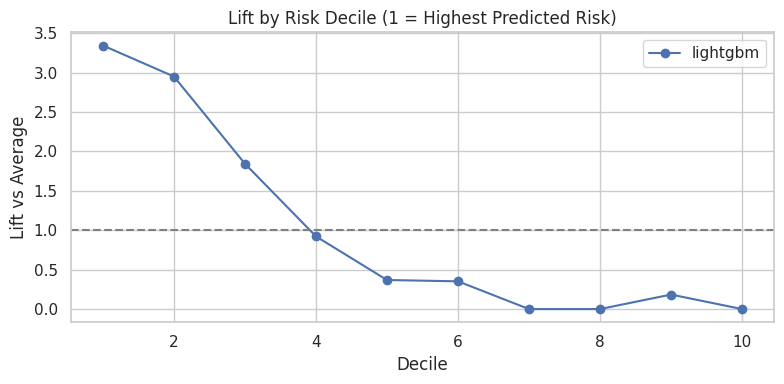

In [12]:
lift_boost = decile_lift_table(y_valid, proba_boost)
print('LightGBM decile lift:')
display(lift_boost)

plt.figure(figsize=(8, 4))
plt.plot(lift_boost['decile'], lift_boost['lift_vs_avg'], marker='o', label='lightgbm')
plt.axhline(1.0, linestyle='--', color='gray')
plt.title('Lift by Risk Decile (1 = Highest Predicted Risk)')
plt.xlabel('Decile')
plt.ylabel('Lift vs Average')
plt.legend()
plt.tight_layout()



lightgbm decile lift:


,decile,n,bad_rate,lift_vs_avg
0,1,22,0.863636,3.344628
1,2,21,0.761905,2.950649
2,3,21,0.476190,1.844156
3,4,21,0.238095,0.922078
4,5,21,0.095238,0.368831
5,6,22,0.090909,0.352066
6,7,21,0.000000,0.000000
7,8,21,0.000000,0.000000
8,9,21,0.047619,0.184416
9,10,22,0.000000,0.000000


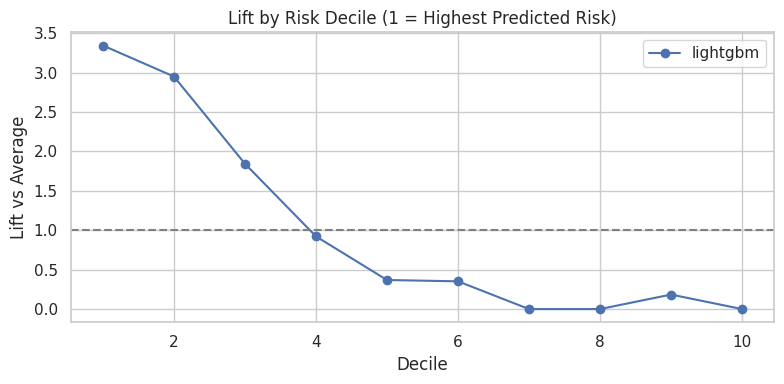

In [13]:
proba_lr_local = globals().get('proba_lr', None)
proba_boost_local = globals().get('proba_boost', None)
boost_model_name_local = globals().get('boost_model_name', 'boost_model')
y_valid_local = globals().get('y_valid', None)

if y_valid_local is None:
    raise RuntimeError('y_valid is missing. Run model training/evaluation cells first.')

if proba_lr_local is not None:
    lift_lr = decile_lift_table(y_valid_local, proba_lr_local)
    print('Logistic regression decile lift:')
    display(lift_lr)
else:
    lift_lr = None

if proba_boost_local is not None:
    lift_boost = decile_lift_table(y_valid_local, proba_boost_local)
    print(f'{boost_model_name_local} decile lift:')
    display(lift_boost)
else:
    lift_boost = None

plt.figure(figsize=(8, 4))
if lift_lr is not None:
    plt.plot(lift_lr['decile'], lift_lr['lift_vs_avg'], marker='o', label='Logistic Regression')
if lift_boost is not None:
    plt.plot(lift_boost['decile'], lift_boost['lift_vs_avg'], marker='o', label=boost_model_name_local)
plt.axhline(1.0, linestyle='--', color='gray')
plt.title('Lift by Risk Decile (1 = Highest Predicted Risk)')
plt.xlabel('Decile')
plt.ylabel('Lift vs Average')
if (lift_lr is not None) or (lift_boost is not None):
    plt.legend()
plt.tight_layout()

## 7. Explainability

,importance
B_3_trend,10
D_43_last,9
D_129_min,8
S_25_std,5
D_55_last,4
D_128_last,4
P_2_mean,4
D_61_min,3
B_9_std,3
P_3_min,3


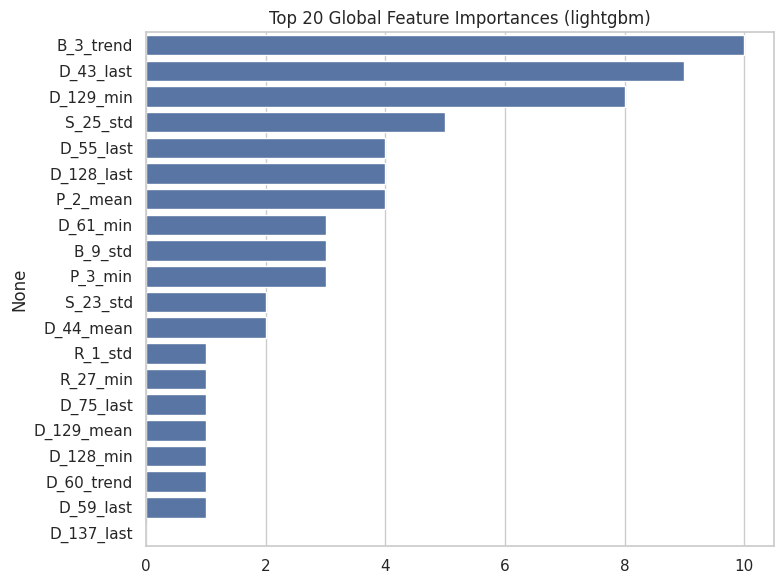

In [14]:
if boost_importance is not None:
    top_imp = boost_importance.sort_values(ascending=False).head(20)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index, orient='h')
    plt.title(f'Top 20 Global Feature Importances ({boost_model_name})')
    plt.tight_layout()

    display(top_imp.to_frame('importance'))

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


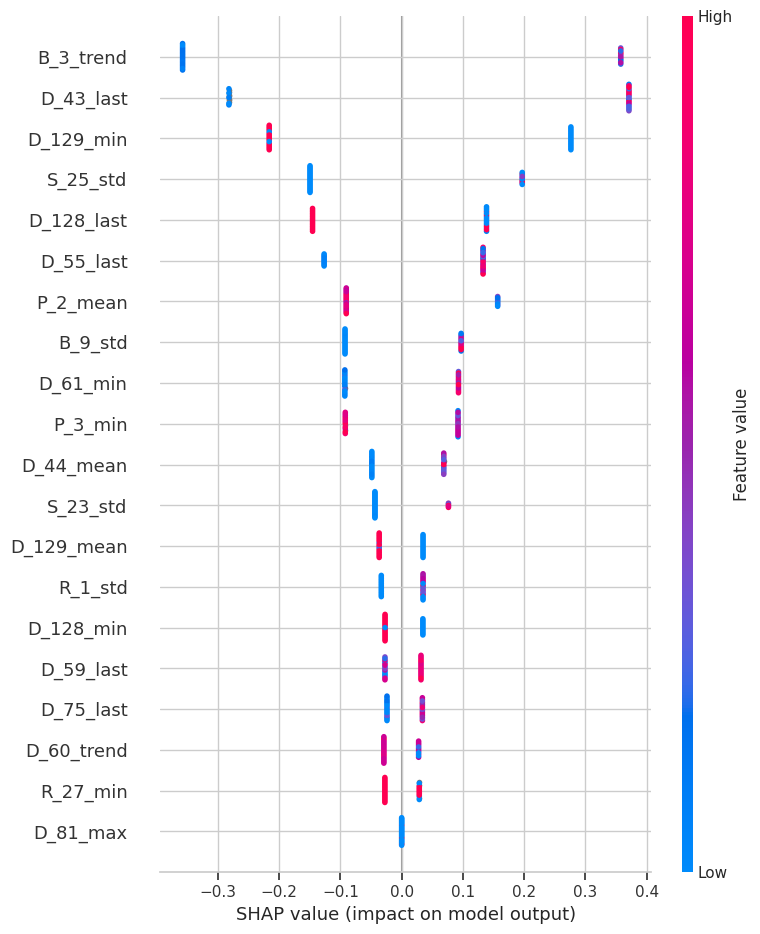

In [15]:
if HAS_SHAP and proba_boost is not None and 'X_valid' in globals() and X_valid is not None and len(X_valid) > 0:
    shap_sample = X_valid.sample(n=min(2000, len(X_valid)), random_state=RANDOM_STATE).copy()

    if boost_model_name == 'lightgbm':
        for c in cat_cols:
            if c in shap_sample.columns:
                shap_sample[c] = shap_sample[c].astype('category')
        explainer = shap.TreeExplainer(gbm)
        shap_values = explainer.shap_values(shap_sample)
        shap.summary_plot(shap_values, shap_sample, show=True)

    elif boost_model_name == 'xgboost':
        shap_sample_enc = shap_sample.copy()
        for c in cat_cols:
            shap_sample_enc[c] = shap_sample_enc[c].astype('category').cat.codes
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(shap_sample_enc)
        shap.summary_plot(shap_values, shap_sample_enc, show=True)
else:
    print('SHAP skipped (missing package/model or no in-memory validation sample).')



print('Segment summary skipped in chunk-only/database-style run. Use sampled valid table if needed.')


In [16]:
valid_df_local = globals().get('valid_df', None)
chunk_mode_local = globals().get('CHUNK_ONLY_MODE', False)
proba_lr_local = globals().get('proba_lr', None)
proba_boost_local = globals().get('proba_boost', None)

if chunk_mode_local or (valid_df_local is None):
    print('Segment summary skipped in chunk-only mode or missing valid_df.')
else:
    analysis_df = valid_df_local[['customer_ID', 'target']].copy()

    if proba_lr_local is not None:
        analysis_df['score'] = proba_lr_local
        score_name = 'logistic_regression'
    elif proba_boost_local is not None:
        analysis_df['score'] = proba_boost_local
        score_name = globals().get('boost_model_name', 'boost_model')
    else:
        raise RuntimeError('No model scores found. Run a model prediction cell first.')

    analysis_df['risk_decile'] = pd.qcut(analysis_df['score'].rank(method='first'), 10, labels=False) + 1
    analysis_df['risk_decile'] = 11 - analysis_df['risk_decile']

    key_behavior_cols = [
        c for c in valid_df_local.columns
        if c.endswith('_trend') or c.endswith('_std') or c.endswith('_missing_rate')
    ]
    key_behavior_cols = key_behavior_cols[:12]

    segment_view = valid_df_local[['customer_ID'] + key_behavior_cols].merge(
        analysis_df[['customer_ID', 'risk_decile', 'target']],
        on='customer_ID', how='left'
    )

    segment_summary = (
        segment_view.groupby('risk_decile')[key_behavior_cols + ['target']]
        .mean()
        .sort_index()
    )

    print(f'Segment summary based on: {score_name}')
    display(segment_summary.head(10))



Segment summary skipped in chunk-only mode or missing valid_df.


## 9. Interview Talking Points

- Why time-aware validation matters: random splits can leak future behavior into training; customer last-statement split is safer.
- Feature design: recency, volatility (`std`), directional trend (`trend`), and missingness patterns often carry default signals.
- Baseline progression: start linear for interpretability, then use gradient boosting to capture nonlinearity and interactions.
- Business usage: decile lift supports risk-tier policying (collections prioritization, credit line review, proactive outreach).
- Next improvements: target encoding with out-of-fold strategy, sequence models, and monotonic constraints for risk governance.

## 10. Load Test Data Only

Load test parquet once, then reuse `test_raw` in submission cells.


In [20]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
TEST_PATH = BASE_DIR / 'test_data.parquet'

if (not RETRAIN_FEATURES) and TEST_FEATURE_PATH.exists():
    test_raw = None
    print(f'Skipping raw test load. Using cached test features: {TEST_FEATURE_PATH}')
else:
    if not TEST_PATH.exists():
        raise FileNotFoundError(f'Missing test file: {TEST_PATH}')
    test_raw = pd.read_parquet(TEST_PATH)
    test_raw['S_2'] = pd.to_datetime(test_raw['S_2'])
    print('Loaded test_raw:', test_raw.shape)
    test_raw.head(3)

test_raw = pd.read_parquet(TEST_PATH)
test_raw['S_2'] = pd.to_datetime(test_raw['S_2'])
print('Loaded test_raw:', test_raw.shape)
test_raw.head(3)

Skipping raw test load. Using cached test features: /content/drive/MyDrive/amex_data_parquet/features/customer_features_test.parquet
Loaded test_raw: (11363762, 190)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-02-19,0.631315,0.001912,0.010728,0.814497,0.007547,0.168651,0.009971,0.002347,0.113189,NaN,0.007584,0.116402,0.004483,0.009517,0.005178,NaN,0.474383,0.626467,NaN,0.174591,1.250677,1.003925,NaN,0.008718,0.001013,0.103590,0.119043,NaN,-0.002919,NaN,0.002771,0.004416,1.006875,1.005069,0.002810,0.105587,0.119198,0.321676,0.114564,NaN,NaN,0.003420,0.205898,NaN,0.010182,NaN,0.027472,0.588734,0.010489,1.881856,0.051811,CR,None,0.008294,0.008663,NaN,0.592103,0.009144,NaN,0.004986,NaN,0.190516,0.002675,0.409411,0.009990,NaN,0.005210,NaN,0.014684,0.004310,0.400602,1.134792,0.178862,0.959531,0.217694,0.20459,NaN,0.009799,0.007748,0.002916,0.006896,0.001656,0.004356,NaN,0.002008,NaN,0.002531,0.000348,0.001173,0.004170,0.004585,0.002291,0.508240,0.005093,1.002944,0.133804,0.004322,NaN,0.008857,0.004144,0.009563,0.006942,NaN,0.0,0.003684,0.009909,NaN,0.008908,0.002955,NaN,1,0.008999,0.003418,0.002200,0.003781,0.002948,0.004635,1.003810,0.006653,0.007474,0.000192,NaN,0.008761,0.000835,0.004389,0.004115,0.008442,0.009575,0.981078,0.134916,0.954664,0.971086,0.006562,0.002419,NaN,NaN,NaN,NaN,NaN,0.008146,0.007970,NaN,NaN,1.0,NaN,0.005124,NaN,NaN,NaN,1.004130,0.274203,0.004302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.006201,NaN,NaN,0.009664,NaN,NaN,NaN,NaN,0.007082,0.005957,NaN,NaN,NaN,NaN,NaN,NaN,0.004669,NaN,NaN,NaN,0.008281,NaN
1,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-03-25,0.587042,0.005275,0.011026,0.810848,0.001817,0.241389,0.000166,0.009132,0.123035,NaN,0.006646,0.134878,0.009497,0.026313,0.009029,NaN,0.473587,0.611682,NaN,0.177115,0.234169,1.009301,NaN,0.003146,0.005533,0.101239,0.120991,NaN,0.031222,NaN,0.006497,0.010003,1.005728,1.000432,0.000525,0.160562,0.121490,0.170728,0.184116,NaN,0.028347,0.007156,0.403270,0.014491,0.025130,NaN,0.054790,0.622886,0.021704,2.043278,0.057567,CR,None,0.002011,0.000835,NaN,0.590922,0.000165,NaN,0.001557,NaN,0.190172,0.001771,0.561424,0.008125,NaN,0.008394,0.000606,0.011945,0.002283,0.605887,0.208381,0.179502,0.961667,0.216526,0.20657,NaN,0.004549,0.003098,NaN,0.003682,0.005516,0.001506,0.001013,0.006444,NaN,0.007169,0.003077,0.005880,0.004056,0.009634,0.001225,0.508681,0.007319,1.003831,0.144626,0.005300,NaN,0.001477,0.002083,0.002234,0.005523,NaN,0.0,0.006410,0.007458,NaN,0.000843,0.007457,NaN,1,0.005120,0.002382,0.006557,0.001691,0.004449,0.000574,1.004629,0.004394,0.001169,0.006693,NaN,0.004318,0.008072,0.007888,0.007656,0.006347,0.006952,0.966995,0.138531,0.957019,0.975003,0.004611,0.006549,0.003031,0.008755,NaN,NaN,0.004698,0.000078,0.015463,NaN,1.007666,1.0,NaN,0.000610,NaN,NaN,NaN,1.004495,0.353639,0.276623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.003833,0.008782,0.005579,0.007441,NaN,0.007598,0.008074,NaN,0.007188,0.001253,NaN,NaN,NaN,NaN,NaN,0.000142,0.004940,0.009021,NaN,0.003695,0.003753,0.001460
2,00000469ba478561f23a92a868bd366de6f6527a684c9a...,2019-04-25,0.609056,0.003326,0.016390,1.004620,0.000114,0.266976,0.004196,0.004192,0

In [21]:
def ensure_test_chunks(test_raw: pd.DataFrame | None = None) -> list[Path]:
    chunk_paths = list_chunk_paths(TEST_CHUNK_DIR, 'test')

    expected = [TEST_CHUNK_DIR / f'test_chunk_{i:03d}.parquet' for i in range(N_CHUNKS_TEST)]
    existing_set = set(chunk_paths)
    missing = [cp for cp in expected if cp not in existing_set]

    if chunk_paths and not missing and (not RETRAIN_FEATURES):
        print(f'Using existing complete test chunks: {len(chunk_paths)}/{N_CHUNKS_TEST}')
        return chunk_paths

    if chunk_paths and missing and (not RETRAIN_FEATURES):
        print(f'Resuming test chunk build: {len(chunk_paths)} done, {len(missing)} missing.')
        print('First missing chunk:', missing[0].name)

    if test_raw is None:
        if missing:
            raise RuntimeError(
                f'Test chunks are incomplete ({len(chunk_paths)}/{N_CHUNKS_TEST}). '
                'Load test_raw once to continue building unfinished chunks.'
            )
        raise RuntimeError('Raw test data is required to build test chunks once.')

    # build_feature_chunks_to_disk skips existing chunk files when retrain=False,
    # so this call naturally continues from unfinished chunks only.
    return build_feature_chunks_to_disk(
        test_raw,
        out_dir=TEST_CHUNK_DIR,
        n_chunks=N_CHUNKS_TEST,
        max_trend_cols=TEST_MAX_TREND_COLS,
        prefix='test',
        retrain=RETRAIN_FEATURES,
    )



In [22]:
# Streamed baseline submission generation from test chunks (memory-safe)

test_chunk_paths = ensure_test_chunks(globals().get('test_raw', None))

if MODEL_META_PATH.exists():
    model_meta = json.loads(MODEL_META_PATH.read_text())
else:
    raise RuntimeError('Missing model_meta.json. Train/load model first.')

feature_cols = model_meta['feature_columns']
cat_cols = model_meta.get('categorical_columns', [])

for old in SUBMISSION_PARTS_DIR.glob('part_*.csv'):
    old.unlink()

model_used = 'lightgbm'
for i, cp in enumerate(tqdm(test_chunk_paths, desc='Scoring test chunks')):
    chunk_df = pd.read_parquet(cp)
    if chunk_df.empty:
        continue

    for c in feature_cols:
        if c not in chunk_df.columns:
            chunk_df[c] = np.nan

    x_chunk = _prepare_lgb_frame(chunk_df[feature_cols], cat_cols)
    pred = gbm.predict(x_chunk) if isinstance(gbm, lgb.Booster) else gbm.predict_proba(x_chunk)[:, 1]

    pd.DataFrame({'customer_ID': chunk_df['customer_ID'], 'prediction': pred}).to_csv(
        SUBMISSION_PARTS_DIR / f'part_{i:03d}.csv', index=False
    )

    del chunk_df, x_chunk, pred
    gc.collect()

submission = pd.concat(
    [pd.read_csv(x) for x in sorted(SUBMISSION_PARTS_DIR.glob('part_*.csv'))],
    axis=0,
    ignore_index=True,
)
submission.to_csv(BASELINE_SUBMISSION_PATH, index=False)

submission_meta = {
    'created_at': datetime.utcnow().isoformat(),
    'model_used': model_used,
    'submission_path': str(BASELINE_SUBMISSION_PATH),
    'rows': int(len(submission)),
    'parts': len(list(SUBMISSION_PARTS_DIR.glob('part_*.csv'))),
}
SUBMISSION_META_PATH.write_text(json.dumps(submission_meta, indent=2))

print({'model_used': model_used, 'rows': len(submission), 'saved_to': str(BASELINE_SUBMISSION_PATH)})
submission.head()

Resuming test chunk build: 19 done, 13 missing.
First missing chunk: test_chunk_019.parquet


Building test chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Scoring test chunks:   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipython-input-1186508825.py:44: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at': datetime.utcnow().isoformat(),


{'model_used': 'lightgbm', 'rows': 924621, 'saved_to': '/content/drive/MyDrive/amex_data_parquet/baseline_submission.csv'}


,customer_ID,prediction
0,0003f2bb53707a980d112da4e708360ad46e41c61bf501...,0.372129
1,00066a2610045be9023fb428ceae21dc984e941f38832d...,0.585934
2,00067b43b0deb37c895dceb1e4306064a5a6ee41c0d373...,0.464055
3,0006fe625c516b606344f49cf6e3fae693ed9e9837f3f5...,0.572112
4,000ada1377b0e5267845565718d6b98cfb281ddaa6f5d3...,0.424068


In [23]:
# Streamed baseline submission generation from test chunks (memory-safe)
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/amex_data_parquet')
BASELINE_SUBMISSION_PATH = BASE_DIR / 'baseline_submission.csv'
SUBMISSION_PARTS_DIR = BASE_DIR / 'submission_parts'
SUBMISSION_PARTS_DIR.mkdir(parents=True, exist_ok=True)

for old in SUBMISSION_PARTS_DIR.glob('part_*.csv'):
    old.unlink()

print('Ensuring test feature chunks...')
test_chunk_paths = ensure_test_chunks(globals().get('test_raw', None))

proba_boost_local = globals().get('proba_boost', None)
proba_lr_local = globals().get('proba_lr', None)
logreg_local = globals().get('logreg', None)
boost_model_name_local = globals().get('boost_model_name', None)


if 'feature_cols' not in globals() or feature_cols is None:
    if LGB_META_PATH.exists():
        meta = json.loads(LGB_META_PATH.read_text())
        feature_cols = meta['feature_cols']
        cat_cols = meta.get('cat_cols', [])
    else:
        raise RuntimeError('feature_cols not available. Train/load LightGBM model first.')

for i, cp in enumerate(tqdm(test_chunk_paths, desc='Scoring test chunks')):
    chunk_df = pd.read_parquet(cp)
    if chunk_df.empty:
        continue

    for c in feature_cols:
        if c not in chunk_df.columns:
            chunk_df[c] = np.nan

    x_chunk = chunk_df[feature_cols].copy()

    if proba_boost_local is not None and boost_model_name_local == 'lightgbm':
        x_chunk = _prepare_lgb_frame(x_chunk, cat_cols)
        if isinstance(gbm, lgb.Booster):
            pred = gbm.predict(x_chunk)
        else:
            pred = gbm.predict_proba(x_chunk)[:, 1]
        model_used = 'lightgbm'
    elif proba_lr_local is not None and logreg_local is not None:
        pred = logreg_local.predict_proba(x_chunk)[:, 1]
        model_used = 'logistic_regression'
    else:
        raise RuntimeError('No trained model available for submission.')

    part_out = pd.DataFrame({'customer_ID': chunk_df['customer_ID'], 'prediction': pred})
    part_out.to_csv(SUBMISSION_PARTS_DIR / f'part_{i:03d}.csv', index=False)

    del chunk_df, x_chunk, pred, part_out
    gc.collect()

submission = pd.concat(
    [pd.read_csv(x) for x in sorted(SUBMISSION_PARTS_DIR.glob('part_*.csv'))],
    axis=0,
    ignore_index=True,
)
submission.to_csv(BASELINE_SUBMISSION_PATH, index=False)

print({'model_used': model_used, 'rows': len(submission), 'saved_to': str(BASELINE_SUBMISSION_PATH)})
submission.head()

Ensuring test feature chunks...
Using existing complete test chunks: 32/32


Scoring test chunks:   0%|          | 0/32 [00:00<?, ?it/s]

{'model_used': 'lightgbm', 'rows': 924621, 'saved_to': '/content/drive/MyDrive/amex_data_parquet/baseline_submission.csv'}


,customer_ID,prediction
0,0003f2bb53707a980d112da4e708360ad46e41c61bf501...,0.372129
1,00066a2610045be9023fb428ceae21dc984e941f38832d...,0.585934
2,00067b43b0deb37c895dceb1e4306064a5a6ee41c0d373...,0.464055
3,0006fe625c516b606344f49cf6e3fae693ed9e9837f3f5...,0.572112
4,000ada1377b0e5267845565718d6b98cfb281ddaa6f5d3...,0.424068


In [24]:
print('Advanced flow skipped for 4-layer chunk-only pipeline. Baseline incremental LightGBM is the production path here.')

Advanced flow skipped for 4-layer chunk-only pipeline. Baseline incremental LightGBM is the production path here.


In [25]:
if CHUNK_ONLY_MODE:
    print('Advanced flow skipped in chunk-only mode to keep memory bounded.')
else:
    # Advanced model flow: time-aware CV with two boosted configs + meta logistic
    N_FOLDS = 5
    ADVANCED_SUBMISSION_PATH = BASE_DIR / 'advanced_submission.csv'

    full_model_df = model_df.copy().reset_index(drop=True)
    X_full = full_model_df.drop(columns=EXCLUDE_COLS)
    y_full = full_model_df[TARGET_COL].astype(int)

    adv_cat_cols = [
        c for c in X_full.columns
        if str(X_full[c].dtype) in ('object', 'category')
    ]

    fold_ids = np.zeros(len(full_model_df), dtype=int)
    fold_sizes = np.full(N_FOLDS, len(full_model_df) // N_FOLDS)
    fold_sizes[:len(full_model_df) % N_FOLDS] += 1
    start = 0
    for f, sz in enumerate(fold_sizes):
        end = start + sz
        fold_ids[start:end] = f
        start = end

    def build_lgb_params(config_name: str, use_gpu: bool = False) -> dict:
        if config_name == 'cfg_a':
            params = dict(
                n_estimators=900,
                learning_rate=0.03,
                num_leaves=96,
                min_child_samples=40,
                subsample=0.85,
                colsample_bytree=0.75,
                objective='binary',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        else:
            params = dict(
                n_estimators=1200,
                learning_rate=0.02,
                num_leaves=128,
                min_child_samples=80,
                subsample=0.9,
                colsample_bytree=0.85,
                objective='binary',
                random_state=RANDOM_STATE + 7,
                n_jobs=-1,
            )
        if use_gpu:
            params['device'] = 'gpu'
        return params

    def fit_predict_lgb(train_x, train_y, valid_x, params, cat_cols_local):
        xtr = train_x.copy()
        xva = valid_x.copy()
        for c in cat_cols_local:
            if c in xtr.columns:
                xtr[c] = xtr[c].astype('category')
                xva[c] = xva[c].astype('category')

        model = lgb.LGBMClassifier(**params)
        model.fit(xtr, train_y)
        pred = model.predict_proba(xva)[:, 1]
        return model, pred

    if not HAS_LGBM:
        raise RuntimeError('Advanced flow currently requires LightGBM installed.')

    oof_a = np.zeros(len(X_full), dtype=float)
    oof_b = np.zeros(len(X_full), dtype=float)

    for fold in range(N_FOLDS):
        valid_mask = fold_ids == fold
        train_mask = ~valid_mask

        X_tr = X_full.loc[train_mask]
        y_tr = y_full.loc[train_mask]
        X_va = X_full.loc[valid_mask]

        params_a = build_lgb_params('cfg_a', use_gpu=GPU_AVAILABLE)
        params_b = build_lgb_params('cfg_b', use_gpu=GPU_AVAILABLE)

        model_a, pred_a = fit_predict_lgb(X_tr, y_tr, X_va, params_a, adv_cat_cols)
        model_b, pred_b = fit_predict_lgb(X_tr, y_tr, X_va, params_b, adv_cat_cols)

        oof_a[valid_mask] = pred_a
        oof_b[valid_mask] = pred_b
        print(f'Fold {fold + 1}/{N_FOLDS} done.')

    meta_X = pd.DataFrame({'pred_a': oof_a, 'pred_b': oof_b, 'pred_mean': 0.5 * (oof_a + oof_b)})
    meta_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    meta_model.fit(meta_X, y_full)
    meta_oof_pred = meta_model.predict_proba(meta_X)[:, 1]

    auc_adv = roc_auc_score(y_full, meta_oof_pred)
    pr_auc_adv = average_precision_score(y_full, meta_oof_pred)
    print({'advanced_meta_auc_oof': round(auc_adv, 5), 'advanced_meta_pr_auc_oof': round(pr_auc_adv, 5)})



Advanced flow skipped in chunk-only mode to keep memory bounded.
